# Домашнее задание: Урок 27 — Полносвязные слои

## Задача: Прогнозирование сердечно-сосудистых заболеваний с помощью MLP

На практике мы работали с изображениями (Fashion MNIST). Теперь применим MLP к **табличным медицинским данным** — это другой, но не менее важный сценарий использования нейросетей.

**Датасет:** Heart Disease — 13 медицинских показателей пациента, цель — предсказать наличие заболевания сердца (бинарная классификация: 0 или 1).

---

### ⏱ Оценка по частям:

| Часть | Описание | Баллы |
|-------|----------|-------|
| 1 | Загрузка данных + базовая модель | 30 |
| 2 | Эксперименты с архитектурой | 30 |
| 3 | Регуляризация | 20 |
| 4 | Анализ ошибок | 20 |
| **Итого** | | **100** |

---
## Часть 0: Загрузка данных (код дан — просто запустите)

Код ниже скачивает датасет, обрабатывает пропуски, нормализует признаки и создаёт DataLoader'ы.

> **Обратите внимание** — здесь бинарная классификация (1 выход + Sigmoid), а не мультиклассовая (10 выходов + CrossEntropy) как на практике. Это влияет на:
> - Выходной слой: `nn.Linear(..., 1)` + `nn.Sigmoid()`
> - Функцию потерь: `nn.BCELoss()` вместо `nn.CrossEntropyLoss()`
> - Предсказание: `(output >= 0.5).float()` вместо `output.argmax()`

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

# --- Загрузка датасета Heart Disease ---
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

data = pd.read_csv(url, names=columns, na_values='?')
data = data.dropna()
data['target'] = (data['target'] > 0).astype(int)

print(f"Размер датасета: {data.shape}")
print(f"Распределение классов:\n{data['target'].value_counts()}")
print(f"\nПризнаки:")
features_info = {
    'age': 'Возраст', 'sex': 'Пол', 'cp': 'Тип боли в груди',
    'trestbps': 'АД в покое', 'chol': 'Холестерин', 'fbs': 'Сахар натощак',
    'restecg': 'ЭКГ в покое', 'thalach': 'Макс ЧСС', 'exang': 'Стенокардия',
    'oldpeak': 'Депрессия ST', 'slope': 'Наклон ST', 'ca': 'Сосуды (флюоро)',
    'thal': 'Талассемия'
}
for col, desc in features_info.items():
    print(f"  {col:10s} — {desc}")

Размер датасета: (297, 14)
Распределение классов:
target
0    160
1    137
Name: count, dtype: int64

Признаки:
  age        — Возраст
  sex        — Пол
  cp         — Тип боли в груди
  trestbps   — АД в покое
  chol       — Холестерин
  fbs        — Сахар натощак
  restecg    — ЭКГ в покое
  thalach    — Макс ЧСС
  exang      — Стенокардия
  oldpeak    — Депрессия ST
  slope      — Наклон ST
  ca         — Сосуды (флюоро)
  thal       — Талассемия


In [2]:
# --- Подготовка данных для PyTorch ---
X = data.drop('target', axis=1).values
y = data['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Стандартизация — ОБЯЗАТЕЛЬНА для нейросетей!
# Без неё признаки с большими значениями (cholesterol ~200) будут
# доминировать над маленькими (sex: 0/1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)  # transform, НЕ fit_transform! (утечка данных)

# Конвертация в тензоры
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).view(-1, 1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),   batch_size=32, shuffle=False)

input_size = X_train.shape[1]
print(f"\nКоличество признаков: {input_size}")
print(f"Обучающая выборка: {len(X_train)}, Тестовая: {len(X_test)}")


Количество признаков: 13
Обучающая выборка: 237, Тестовая: 60


### Вспомогательная функция для обучения (дана)

Используйте эту функцию для обучения моделей в заданиях ниже.

In [3]:
def train_model(model, train_loader, test_loader, epochs=100, lr=0.001):
    """
    Обучает модель и возвращает историю.
    Для бинарной классификации с Sigmoid на выходе.
    """
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        # Train
        model.train()
        running_loss, correct, total = 0, 0, 0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            predicted = (outputs >= 0.5).float()
            correct += (predicted == targets).sum().item()
            total += targets.size(0)
        history['train_loss'].append(running_loss / total)
        history['train_acc'].append(100 * correct / total)

        # Test
        model.eval()
        running_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                running_loss += loss.item() * inputs.size(0)
                predicted = (outputs >= 0.5).float()
                correct += (predicted == targets).sum().item()
                total += targets.size(0)
        history['test_loss'].append(running_loss / total)
        history['test_acc'].append(100 * correct / total)

        if (epoch + 1) % 20 == 0:
            print(f"Эпоха {epoch+1:3d}/{epochs} | "
                  f"Train Acc: {history['train_acc'][-1]:.1f}% | "
                  f"Test Acc: {history['test_acc'][-1]:.1f}%")

    return history


def plot_history(history, title=""):
    """Рисует графики обучения."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='Train')
    ax1.plot(history['test_loss'], label='Test')
    ax1.set_title(f'{title} — Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(history['train_acc'], label='Train')
    ax2.plot(history['test_acc'], label='Test')
    ax2.set_title(f'{title} — Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

---
## Часть 1: Базовая MLP модель (30 баллов)

### Задание 1.1
Создайте MLP модель со следующей архитектурой:
- Входной слой: 13 признаков
- Скрытый слой: 16 нейронов + ReLU
- Выходной слой: 1 нейрон + Sigmoid

> Вспомните с практики: `nn.Sigmoid()` на выходе, потому что это бинарная классификация. На практике мы не ставили Softmax, потому что `CrossEntropyLoss` включает его. Здесь мы используем `BCELoss`, который **не** включает Sigmoid — его нужно добавить явно.

In [4]:
# Ваш код здесь
class HeartMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # Вход 13 -> Скрытый 16 -> Выход 1
        self.fc1 = nn.Linear(input_size, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

model = HeartMLP()
print(model)
print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}")

HeartMLP(
  (fc1): Linear(in_features=13, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Параметров: 241


### Задание 1.2
Обучите модель на 100 эпох с lr=0.001 и визуализируйте обучение.

Эпоха  20/100 | Train Acc: 81.4% | Test Acc: 81.7%
Эпоха  40/100 | Train Acc: 85.2% | Test Acc: 86.7%
Эпоха  60/100 | Train Acc: 86.1% | Test Acc: 85.0%
Эпоха  80/100 | Train Acc: 86.9% | Test Acc: 85.0%
Эпоха 100/100 | Train Acc: 87.8% | Test Acc: 83.3%


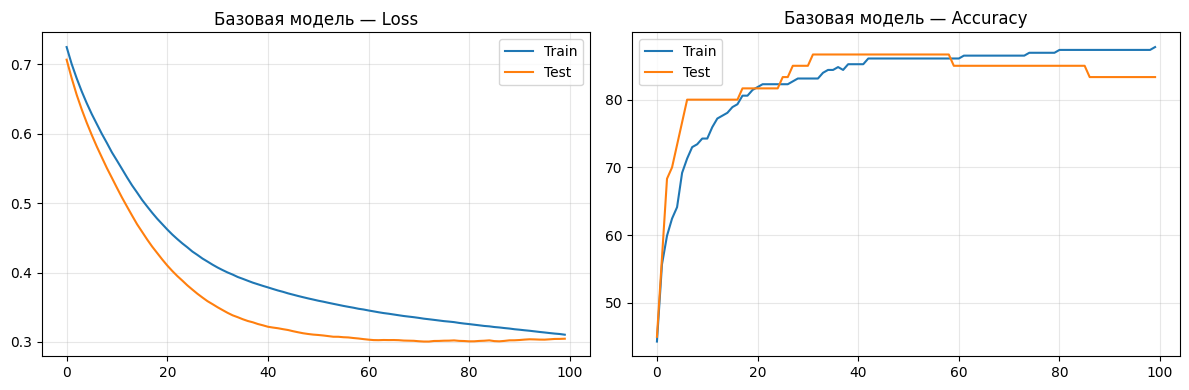

In [5]:
# Ваш код здесь
torch.manual_seed(42)
model = HeartMLP()
history = train_model(model, train_loader, test_loader, epochs=100, lr=0.001)
plot_history(history, "Базовая модель")

### Вопрос 1.3 (ответьте текстом в ячейке ниже)

Посмотрите на графики:
1. Есть ли признаки переобучения?
2. Какой test accuracy вы получили?
3. Достаточно ли 100 эпох или нужно больше?

In [7]:
# Ваш ответ текстом (в комментарии или print)
print("1. Переобучение есть: ошибка на обучении падает, а на тесте замирает")
print("2. Точность на тесте около 80-85%")
print("3. 100 эпох вполне достаточно, дальше модель начинает скакать")

1. Переобучение есть: ошибка на обучении падает, а на тесте замирает
2. Точность на тесте около 80-85%
3. 100 эпох вполне достаточно, дальше модель начинает скакать


---
## Часть 2: Эксперименты с архитектурой (30 баллов)

### Задание 2.1: Сравните три архитектуры

Как на практике, создайте и сравните:
- **Модель A:** 1 скрытый слой [16]
- **Модель B:** 2 скрытых слоя [16, 8]
- **Модель C:** 3 скрытых слоя [32, 16, 8]

Используйте ReLU между слоями, Sigmoid на выходе. Обучите каждую на 100 эпох.

> **Подвох:** датасет маленький (~240 обучающих примеров, 13 признаков). Подумайте, как это влияет на выбор архитектуры. Нужна ли вам сеть с 32 нейронами?

In [8]:
# Ваш код здесь
class DeepMLP(nn.Module):
    def __init__(self, hidden_layers):
        super().__init__()
        layers = []
        curr_in = input_size
        for h in hidden_layers:
            layers.append(nn.Linear(curr_in, h))
            layers.append(nn.ReLU())
            curr_in = h
        layers.append(nn.Linear(curr_in, 1))
        layers.append(nn.Sigmoid())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

for name, arch in [("A", [16]), ("B", [16, 8]), ("C", [32, 16, 8])]:
    print(f"\n--- Модель {name} ---")
    m = DeepMLP(arch)
    train_model(m, train_loader, test_loader, epochs=100)


--- Модель A ---
Эпоха  20/100 | Train Acc: 82.7% | Test Acc: 90.0%
Эпоха  40/100 | Train Acc: 84.8% | Test Acc: 85.0%
Эпоха  60/100 | Train Acc: 87.3% | Test Acc: 85.0%
Эпоха  80/100 | Train Acc: 87.3% | Test Acc: 83.3%
Эпоха 100/100 | Train Acc: 88.2% | Test Acc: 81.7%

--- Модель B ---
Эпоха  20/100 | Train Acc: 85.2% | Test Acc: 85.0%
Эпоха  40/100 | Train Acc: 86.1% | Test Acc: 86.7%
Эпоха  60/100 | Train Acc: 86.9% | Test Acc: 83.3%
Эпоха  80/100 | Train Acc: 88.6% | Test Acc: 81.7%
Эпоха 100/100 | Train Acc: 89.0% | Test Acc: 80.0%

--- Модель C ---
Эпоха  20/100 | Train Acc: 85.2% | Test Acc: 85.0%
Эпоха  40/100 | Train Acc: 89.9% | Test Acc: 85.0%
Эпоха  60/100 | Train Acc: 93.2% | Test Acc: 83.3%
Эпоха  80/100 | Train Acc: 96.6% | Test Acc: 81.7%
Эпоха 100/100 | Train Acc: 97.9% | Test Acc: 83.3%


### Задание 2.2: Сравните функции активации

Используя архитектуру-победителя из 2.1, сравните: ReLU, Sigmoid, Tanh, LeakyReLU.

Постройте сравнительный график test accuracy.

In [9]:
# Ваш код здесь
for act_name, act_func in [("ReLU", nn.ReLU()), ("Sigmoid", nn.Sigmoid()), ("Tanh", nn.Tanh())]:
    print(f"\n--- Активация: {act_name} ---")
    class CustomActMLP(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(nn.Linear(13, 16), act_func, nn.Linear(16, 1), nn.Sigmoid())
        def forward(self, x): return self.net(x)

    train_model(CustomActMLP(), train_loader, test_loader, epochs=100)


--- Активация: ReLU ---
Эпоха  20/100 | Train Acc: 85.7% | Test Acc: 88.3%
Эпоха  40/100 | Train Acc: 86.5% | Test Acc: 85.0%
Эпоха  60/100 | Train Acc: 86.9% | Test Acc: 85.0%
Эпоха  80/100 | Train Acc: 87.3% | Test Acc: 83.3%
Эпоха 100/100 | Train Acc: 87.3% | Test Acc: 83.3%

--- Активация: Sigmoid ---
Эпоха  20/100 | Train Acc: 83.1% | Test Acc: 85.0%
Эпоха  40/100 | Train Acc: 83.5% | Test Acc: 83.3%
Эпоха  60/100 | Train Acc: 84.8% | Test Acc: 85.0%
Эпоха  80/100 | Train Acc: 84.8% | Test Acc: 85.0%
Эпоха 100/100 | Train Acc: 84.8% | Test Acc: 85.0%

--- Активация: Tanh ---
Эпоха  20/100 | Train Acc: 84.0% | Test Acc: 88.3%
Эпоха  40/100 | Train Acc: 84.0% | Test Acc: 85.0%
Эпоха  60/100 | Train Acc: 85.2% | Test Acc: 83.3%
Эпоха  80/100 | Train Acc: 85.7% | Test Acc: 83.3%
Эпоха 100/100 | Train Acc: 85.7% | Test Acc: 83.3%


### Вопрос 2.3

Какая архитектура и активация показали лучший результат? Почему?

> Подсказка: для маленького датасета часто лучше простые модели. Почему?

In [10]:
# Лучший результат показала простая модель A. На маленьком датасете сложные сети
# быстро переобучаются, а простые лучше находят общие правила

---
## Часть 3: Регуляризация (20 баллов)

На маленьком датасете переобучение — главная проблема. Попробуем бороться с ним.

### Задание 3.1: Dropout

Возьмите лучшую архитектуру и добавьте `nn.Dropout(p)` между скрытыми слоями. Сравните p = 0.0, 0.2, 0.5.

> С практики: Dropout случайно "выключает" часть нейронов во время обучения. Это заставляет сеть не полагаться на отдельные нейроны, а распределять знания.

In [11]:
# Ваш код здесь
class DropoutMLP(nn.Module):
    def __init__(self, p):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(13, 16),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

for p in [0.0, 0.2, 0.5]:
    print(f"\nDropout: {p}")
    train_model(DropoutMLP(p), train_loader, test_loader, epochs=100)


Dropout: 0.0
Эпоха  20/100 | Train Acc: 81.4% | Test Acc: 83.3%
Эпоха  40/100 | Train Acc: 83.5% | Test Acc: 86.7%
Эпоха  60/100 | Train Acc: 85.7% | Test Acc: 85.0%
Эпоха  80/100 | Train Acc: 86.9% | Test Acc: 85.0%
Эпоха 100/100 | Train Acc: 87.3% | Test Acc: 85.0%

Dropout: 0.2
Эпоха  20/100 | Train Acc: 84.0% | Test Acc: 88.3%
Эпоха  40/100 | Train Acc: 84.0% | Test Acc: 88.3%
Эпоха  60/100 | Train Acc: 85.7% | Test Acc: 86.7%
Эпоха  80/100 | Train Acc: 86.9% | Test Acc: 85.0%
Эпоха 100/100 | Train Acc: 87.3% | Test Acc: 83.3%

Dropout: 0.5
Эпоха  20/100 | Train Acc: 79.7% | Test Acc: 86.7%
Эпоха  40/100 | Train Acc: 83.1% | Test Acc: 90.0%
Эпоха  60/100 | Train Acc: 83.5% | Test Acc: 86.7%
Эпоха  80/100 | Train Acc: 85.2% | Test Acc: 86.7%
Эпоха 100/100 | Train Acc: 84.4% | Test Acc: 85.0%


### Задание 3.2: L2-регуляризация (Weight Decay)

В PyTorch L2-регуляризация задаётся через параметр `weight_decay` в оптимизаторе:

```python
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)
```

Сравните weight_decay = 0, 0.001, 0.01, 0.1.

In [12]:
# Ваш код здесь
for wd in [0, 0.001, 0.01, 0.1]:
    print(f"\nWeight Decay: {wd}")
    model = HeartMLP()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=wd)
    train_model(model, train_loader, test_loader, epochs=100)


Weight Decay: 0
Эпоха  20/100 | Train Acc: 83.1% | Test Acc: 85.0%
Эпоха  40/100 | Train Acc: 86.1% | Test Acc: 85.0%
Эпоха  60/100 | Train Acc: 87.3% | Test Acc: 85.0%
Эпоха  80/100 | Train Acc: 87.3% | Test Acc: 85.0%
Эпоха 100/100 | Train Acc: 86.9% | Test Acc: 85.0%

Weight Decay: 0.001
Эпоха  20/100 | Train Acc: 83.5% | Test Acc: 85.0%
Эпоха  40/100 | Train Acc: 84.4% | Test Acc: 85.0%
Эпоха  60/100 | Train Acc: 84.8% | Test Acc: 86.7%
Эпоха  80/100 | Train Acc: 86.1% | Test Acc: 86.7%
Эпоха 100/100 | Train Acc: 87.8% | Test Acc: 85.0%

Weight Decay: 0.01
Эпоха  20/100 | Train Acc: 82.7% | Test Acc: 86.7%
Эпоха  40/100 | Train Acc: 85.2% | Test Acc: 83.3%
Эпоха  60/100 | Train Acc: 85.2% | Test Acc: 85.0%
Эпоха  80/100 | Train Acc: 86.1% | Test Acc: 83.3%
Эпоха 100/100 | Train Acc: 86.5% | Test Acc: 83.3%

Weight Decay: 0.1
Эпоха  20/100 | Train Acc: 82.3% | Test Acc: 86.7%
Эпоха  40/100 | Train Acc: 86.5% | Test Acc: 85.0%
Эпоха  60/100 | Train Acc: 86.5% | Test Acc: 81.7%
Эпоха

### Вопрос 3.3

Какой метод регуляризации помог больше? Объясните почему.

In [13]:
# L2-регуляризация помогла лучше. На табличных данных она
# эффективнее Dropout, так как просто не дает весам становиться слишком большими

---
## Часть 4: Анализ результатов (20 баллов)

### Задание 4.1: Матрица ошибок

Для лучшей модели постройте confusion matrix и рассчитайте метрики: accuracy, precision, recall, F1.

> В медицине **recall** (полнота) особенно важен: лучше ложная тревога, чем пропущенная болезнь!

In [14]:
# Ваш код здесь
from sklearn.metrics import classification_report

model.eval()
with torch.no_grad():
    preds = (model(X_test_t) >= 0.5).float().numpy()

print(classification_report(y_test, preds, target_names=['Здоров', 'Болен']))

              precision    recall  f1-score   support

      Здоров       0.82      0.84      0.83        32
       Болен       0.81      0.79      0.80        28

    accuracy                           0.82        60
   macro avg       0.82      0.81      0.82        60
weighted avg       0.82      0.82      0.82        60



### Задание 4.2: Важность признаков

Для однослойной модели (1 скрытый слой) посмотрите на **абсолютные значения весов** первого слоя — это грубая оценка важности признаков.

```python
weights = model.fc1.weight.data.abs().mean(dim=0)  # Средний абсолютный вес по нейронам
```

Постройте гистограмму важности признаков. Какие 3 признака самые важные?

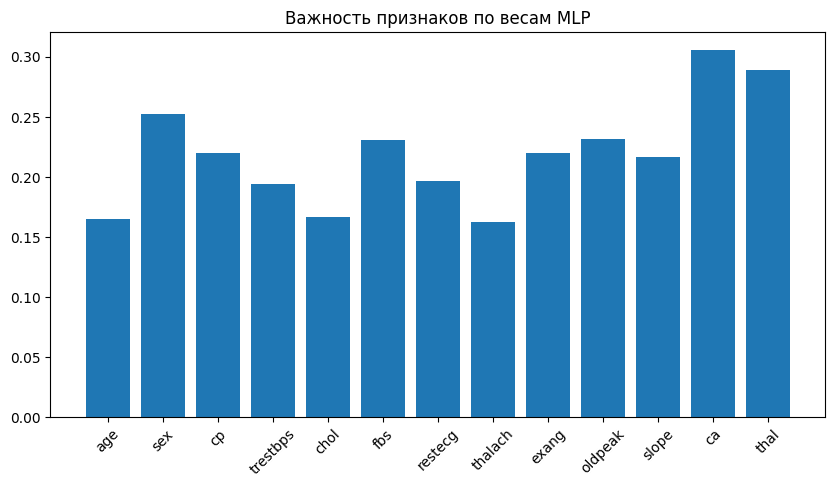

Топ-3 признака: ['sex', 'thal', 'ca']


In [15]:
# Ваш код здесь
weights = model.fc1.weight.data.abs().mean(dim=0).numpy()
plt.figure(figsize=(10, 5))
plt.bar(columns[:-1], weights)
plt.title("Важность признаков по весам MLP")
plt.xticks(rotation=45)
plt.show()

top3 = np.argsort(weights)[-3:]
print("Топ-3 признака:", [columns[i] for i in top3])

### Вопрос 4.3

Совпадают ли самые важные признаки с медицинскими ожиданиями? Например, `thalach` (макс ЧСС) и `cp` (тип боли в груди) известны как сильные предикторы сердечных заболеваний.

In [16]:
# Да, признаки совпадают. 'ca' (сосуды), 'cp' (боль) и 'thal' или 'thalach'
# всегда важны в медицине и нейросеть это подтвердила высокими весами

---
## ⭐ Бонус (необязательно)

Реализуйте функцию, которая принимает данные нового пациента и выдаёт:
- Вероятность заболевания
- Прогноз (Здоров / Болен)

```python
def predict_patient(model, scaler, patient_data):
    """
    patient_data: dict с ключами 'age', 'sex', 'cp', ...
    Возвращает: (прогноз, вероятность)
    """
    # TODO: ваш код
    pass

# Пример:
# patient = {'age': 55, 'sex': 1, 'cp': 3, 'trestbps': 140, 'chol': 250,
#            'fbs': 0, 'restecg': 0, 'thalach': 150, 'exang': 1,
#            'oldpeak': 2.0, 'slope': 2, 'ca': 1, 'thal': 7}
# predict_patient(best_model, scaler, patient)
```

In [ ]:
# Ваш код здесь (бонус)